<a href="https://www.kaggle.com/code/manognamannala/rq2-revenue-prediction?scriptVersionId=316848697" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ2: Revenue Prediction

**Research question:** To what extent can box-office revenue be predicted from budget, genre, language, production company, cast, director, runtime, and movie text features?

This Kaggle-ready notebook loads the raw CSV/Excel dataset, creates the required actual answer table(s), and saves the final figure as a PDF.

In [1]:

# =========================
# Common setup and utilities
# =========================

import os
import ast
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

# Change this only if your Kaggle input folder has a different path.
# On Kaggle, this usually works automatically:
KAGGLE_INPUT_ROOT = "/kaggle/input"

OUTPUT_DIR = "/kaggle/working"
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_dataset_file():
    """
    Finds the first CSV or Excel file in Kaggle input folders.
    Also works locally if the dataset is in the current folder.
    """
    search_patterns = [
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.csv"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xlsx"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xls"),
        "*.csv",
        "*.xlsx",
        "*.xls"
    ]
    files = []
    for pattern in search_patterns:
        files.extend(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError("No CSV or Excel dataset file found. Check Kaggle input path.")
    # Prefer files with movie-related names if multiple files exist.
    movie_like = [f for f in files if "movie" in os.path.basename(f).lower()]
    return movie_like[0] if movie_like else files[0]

def load_raw_dataset():
    file_path = find_dataset_file()
    print("Loading dataset from:", file_path)
    if file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
    print("Shape:", df.shape)
    return df

def safe_literal_list(x):
    """
    Converts stringified Python lists like "['Drama', 'Comedy']" into actual lists.
    Returns [] for missing or invalid values.
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return []
    x = x.strip()
    if x == "" or x == "[]":
        return []
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return [str(v).strip() for v in val if str(v).strip()]
        return []
    except Exception:
        # Fallback for comma-separated strings
        return [v.strip() for v in x.split(",") if v.strip()]

def prepare_base_dataframe(df):
    """
    Cleans and creates derived variables used across the research questions.
    """
    df = df.copy()

    # Standardize expected column names
    df.columns = [c.strip() for c in df.columns]

    # Date features
    if "release_date" in df.columns:
        df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
        df["release_year"] = df["release_date"].dt.year
        df["release_month"] = df["release_date"].dt.month
    else:
        df["release_year"] = np.nan
        df["release_month"] = np.nan

    # Ensure expected numeric columns exist
    for col in ["runtime", "popularity", "vote_average", "vote_count", "budget", "revenue"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Parse list-like columns
    for col in ["genres", "keywords", "cast", "production_companies", "production_countries", "spoken_languages"]:
        if col not in df.columns:
            df[col] = ""
        df[col + "_list"] = df[col].apply(safe_literal_list)

    # Text variables
    for col in ["overview", "keywords", "tagline", "title", "director", "language"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    # Derived variables
    df["genre_count"] = df["genres_list"].apply(len)
    df["keyword_count"] = df["keywords_list"].apply(len)
    df["cast_size"] = df["cast_list"].apply(len)
    df["production_company_count"] = df["production_companies_list"].apply(len)
    df["spoken_language_count"] = df["spoken_languages_list"].apply(len)
    df["overview_length"] = df["overview"].fillna("").astype(str).str.split().apply(len)
    df["tagline_length"] = df["tagline"].fillna("").astype(str).str.split().apply(len)
    df["has_tagline"] = (df["tagline"].str.strip() != "").astype(int)
    df["log_budget"] = np.log1p(df["budget"].fillna(0))
    df["log_revenue"] = np.log1p(df["revenue"].fillna(0))
    df["log_vote_count"] = np.log1p(df["vote_count"].fillna(0))

    # Combined text for TF-IDF
    df["combined_text"] = (
        df["overview"].fillna("") + " " +
        df["keywords"].fillna("") + " " +
        df["tagline"].fillna("")
    )

    # First genre for descriptive tables/charts
    df["primary_genre"] = df["genres_list"].apply(lambda x: x[0] if len(x) else "Unknown")

    return df

def add_top_genre_columns(df, top_n=15):
    """
    Multi-hot encodes the most frequent genres and adds them as columns.
    """
    df = df.copy()
    all_genres = pd.Series([g for sublist in df["genres_list"] for g in sublist])
    top_genres = all_genres.value_counts().head(top_n).index.tolist()
    for genre in top_genres:
        df[f"genre_{genre}"] = df["genres_list"].apply(lambda x: int(genre in x))
    return df, [f"genre_{g}" for g in top_genres]

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print("Saved figure:", path)
    return path

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def clean_modeling_data(df, target_col, feature_cols):
    """
    Keeps rows with non-missing target and selected features.
    """
    use_cols = list(dict.fromkeys(feature_cols + [target_col]))
    data = df[use_cols].copy()
    data = data.dropna(subset=[target_col])
    return data

def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features),
            ("text", TfidfVectorizer(max_features=300, stop_words="english"), "combined_text")
        ],
        remainder="drop"
    )

def make_structured_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features)
        ],
        remainder="drop"
    )


Loading dataset from: /kaggle/input/datasets/manognamannala/movies-analyzing-dataset/movies dataset.csv
Shape: (3053, 22)
Saved table: /kaggle/working/RQ2_revenue_model_performance.csv
Saved table: /kaggle/working/RQ2_actual_answer.csv
Saved figure: /kaggle/working/RQ2_figure_revenue_prediction_error.pdf


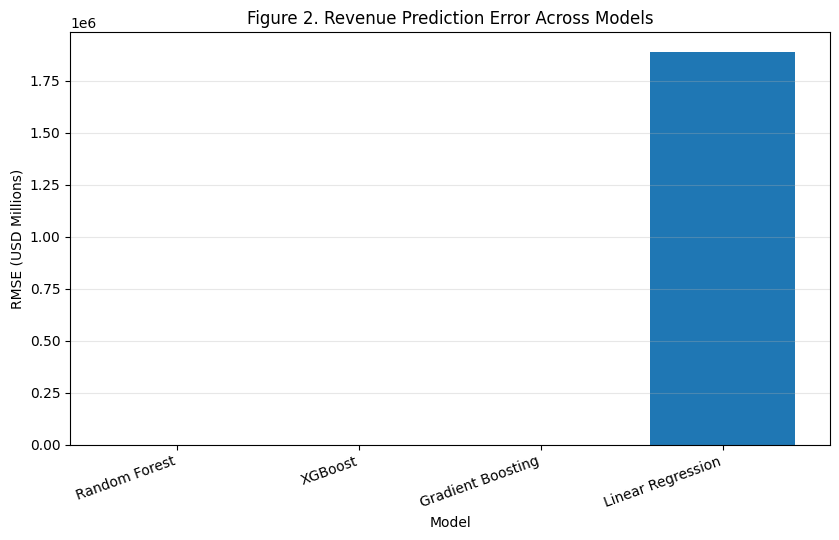

,model,target_variable,n_train,n_test,rmse_log_revenue,mae_log_revenue,r2_log_revenue,rmse_usd,rmse_usd_millions,mae_usd,mae_usd_millions
1,Random Forest,log_revenue,317,106,1.795276,1.108383,0.779768,1.940581e+07,1.940581e+01,9.833143e+06,9.833143
3,XGBoost,log_revenue,317,106,1.887667,1.224632,0.756517,2.334218e+07,2.334218e+01,1.100375e+07,11.003745
2,Gradient Boosting,log_revenue,317,106,1.754492,1.174406,0.789660,2.463134e+07,2.463134e+01,1.152223e+07,11.522226
0,Linear Regression,log_revenue,317,106,5.460058,4.238132,-1.037101,1.887923e+12,1.887923e+06,1.916833e+11,191683.262298


In [2]:

df_raw = load_raw_dataset()
df = prepare_base_dataframe(df_raw)
df, genre_cols = add_top_genre_columns(df)

# Revenue can contain zero values that often represent missing/unknown revenue.
# This notebook uses rows with revenue > 0 for the main revenue-prediction answer.
df_model = df[df["revenue"] > 0].copy()
target = "log_revenue"

numeric_features = [
    "runtime", "release_year", "release_month", "genre_count", "keyword_count",
    "cast_size", "production_company_count", "spoken_language_count",
    "overview_length", "tagline_length", "has_tagline",
    "log_budget", "log_vote_count", "popularity", "vote_average"
] + genre_cols

categorical_features = ["language", "director", "primary_genre"]

feature_cols = numeric_features + categorical_features + ["combined_text"]
data = clean_modeling_data(df_model, target, feature_cols)

X = data[feature_cols]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

preprocessor = make_preprocessor(numeric_features, categorical_features)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

try:
    from xgboost import XGBRegressor
    models["XGBoost"] = XGBRegressor(
        n_estimators=250, learning_rate=0.05, max_depth=4,
        random_state=RANDOM_STATE, objective="reg:squarederror"
    )
except Exception:
    print("XGBoost not available; using Gradient Boosting models only.")

results = []
for model_name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    # Evaluate both log-space and original-dollar-space RMSE.
    y_test_revenue = np.expm1(y_test)
    pred_revenue = np.expm1(pred_log)

    results.append({
        "model": model_name,
        "target_variable": "log_revenue",
        "n_train": len(X_train),
        "n_test": len(X_test),
        "rmse_log_revenue": rmse(y_test, pred_log),
        "mae_log_revenue": mean_absolute_error(y_test, pred_log),
        "r2_log_revenue": r2_score(y_test, pred_log),
        "rmse_usd": rmse(y_test_revenue, pred_revenue),
        "rmse_usd_millions": rmse(y_test_revenue, pred_revenue) / 1_000_000,
        "mae_usd": mean_absolute_error(y_test_revenue, pred_revenue),
        "mae_usd_millions": mean_absolute_error(y_test_revenue, pred_revenue) / 1_000_000
    })

table = pd.DataFrame(results).sort_values("rmse_usd_millions")
save_table(table, "RQ2_revenue_model_performance.csv")

best = table.iloc[0]
answer = pd.DataFrame([{
    "research_question": "RQ2",
    "actual_answer": f"{best['model']} produced the lowest revenue prediction error with RMSE=${best['rmse_usd_millions']:.3f} million and log-revenue R²={best['r2_log_revenue']:.3f}.",
    "best_model": best["model"],
    "best_rmse_usd_millions": best["rmse_usd_millions"],
    "best_r2_log_revenue": best["r2_log_revenue"]
}])
save_table(answer, "RQ2_actual_answer.csv")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(table["model"], table["rmse_usd_millions"])
ax.set_title("Figure 2. Revenue Prediction Error Across Models")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (USD Millions)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
save_figure(fig, "RQ2_figure_revenue_prediction_error.pdf")
plt.show()

table
